# DL060 VAE与ELBO

二维连续与8×8二值图像均实际训练。先做手算，再运行12个600步模型。CPU离线数据，输出notebook_replay，不覆盖参考。

In [1]:
from pathlib import Path
import sys,json,math
import numpy as np
import torch
ROOT=next((p.resolve() for p in [Path.cwd(),Path.cwd()/"units"/"060"] if p.name=="060" and (p/"experiment.py").exists()),None)
if ROOT is None:raise RuntimeError("请从060或课程根目录启动")
sys.path.insert(0,str(ROOT))
from experiment import *
print("Python",sys.version.split()[0],"torch",torch.__version__,"NumPy",np.__version__)


Python 3.12.14 torch 2.14.1+cpu NumPy 2.3.5


## 1 观察两个任务
图像是生成器抽出的真二值观测，不是普通灰度图。

In [2]:
d=make_data()
for k,v in d.items():print(k,v.shape,"range",(v.min(),v.max()))
print("image values",np.unique(d["image_train"]))


xy_train (768, 2) range (np.float32(-2.0074584), np.float32(2.0115452))
image_train (768, 64) range (np.float32(0.0), np.float32(1.0))
xy_validation (192, 2) range (np.float32(-1.9009097), np.float32(1.9232985))
image_validation (192, 64) range (np.float32(0.0), np.float32(1.0))
xy_test (384, 2) range (np.float32(-1.900764), np.float32(2.005817))
image_test (384, 64) range (np.float32(0.0), np.float32(1.0))
image values [0. 1.]


## 2 KL与重参数化梯度
手算KL1.306853,z=(2,-1),mu梯度(1,1),logvar梯度(.5,-.5)。

In [3]:
mu=torch.tensor([[1.,0.]],requires_grad=True)
lv=torch.tensor([[math.log(4),0.]],requires_grad=True)
eps=torch.tensor([[.5,-1.]])
z=reparameterize(mu,lv,eps)
print("KL",kl_standard(mu,lv).item(),"z",z.detach().numpy())
z.sum().backward();print("grad_mu",mu.grad,"grad_logvar",lv.grad)


KL 1.3068528175354004 z [[ 2. -1.]]
grad_mu tensor([[1., 1.]]) grad_logvar tensor([[ 0.5000, -0.5000]])


## 3 观测常数与归约
检查二维Gaussian常数和64像素求和。

In [4]:
x=torch.zeros(1,2)
print("Gaussian D2 sigma1",reconstruction_nll(x,x,"xy",1).item(),math.log(2*math.pi))
x=torch.zeros(1,64)
print("Bernoulli D64",reconstruction_nll(x,x,"image").item(),64*math.log(2))


Gaussian D2 sigma1 1.8378770351409912 1.8378770664093453
Bernoulli D64 44.361419677734375 44.3614195558365


## 4 完整参考检查
12份模型全部逐测试样本重放16次MC，核对干预前缀。

In [5]:
from test_experiment import main as check
check(ROOT/"outputs")


test_kl_and_reparameterization (test_experiment.Checks.test_kl_and_reparameterization) ... 

ok


test_nll_reductions_guards (test_experiment.Checks.test_nll_reductions_guards) ... 

ok


test_saved_full_replay (test_experiment.Checks.test_saved_full_replay) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.093s

OK


## 5 从头训练全部12个模型
两个任务、两个种子、三个预声明beta方案；最后统一评价标准负ELBO。

In [6]:
result=run(ROOT/"notebook_replay")
check(ROOT/"notebook_replay")
print(json.dumps(result["protocol"],ensure_ascii=False,indent=2))


test_kl_and_reparameterization (test_experiment.Checks.test_kl_and_reparameterization) ... 

ok


test_nll_reductions_guards (test_experiment.Checks.test_nll_reductions_guards) ... 

ok


test_saved_full_replay (test_experiment.Checks.test_saved_full_replay) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.087s

OK


{
  "unit": "060",
  "seeds": [
    6001,
    6002
  ],
  "steps": 600,
  "batch": 64,
  "latent_dim": 2,
  "gaussian_sigma": 0.25,
  "reduction": "sum observation and latent coordinates, then mean batch; natural log nats/example",
  "mc_eval_draws": 16,
  "mc_eval_seed": 6099,
  "configs": {
    "standard": "beta1 all600",
    "high_beta": "beta100 all600",
    "restore_beta": "beta100 first300 then beta1 last300"
  },
  "selection": "All predeclared endpoints, no test selection",
  "device": "cpu",
  "threads": 1
}


## 6 同时报告重构KL与配对打乱
beta100是人为压力；图像恢复仍不及standard，不能省略。

In [7]:
for row in result["results"]:print(row)
reference=json.loads((ROOT/"outputs/results.json").read_text())
print("max negative ELBO replay delta",max(abs(a["negative_elbo"]-b["negative_elbo"]) for a,b in zip(result["results"],reference["results"])))


{'kind': 'xy', 'config': 'standard', 'seed': 6001, 'mc_nll': -0.005508289206773043, 'kl': 2.819645643234253, 'negative_elbo': 2.8141372203826904, 'mu_variance': 1.0728672742843628, 'shuffle_nll_delta': 43.36127853393555}
{'kind': 'xy', 'config': 'high_beta', 'seed': 6001, 'mc_nll': 22.10761070251465, 'kl': 0.00019617057114373893, 'negative_elbo': 22.107803344726562, 'mu_variance': 0.00016518938355147839, 'shuffle_nll_delta': 0.022848064079880714}
{'kind': 'xy', 'config': 'restore_beta', 'seed': 6001, 'mc_nll': 0.08417990058660507, 'kl': 2.8316361904144287, 'negative_elbo': 2.915816068649292, 'mu_variance': 1.1735954284667969, 'shuffle_nll_delta': 43.290496826171875}
{'kind': 'xy', 'config': 'standard', 'seed': 6002, 'mc_nll': 0.03310437873005867, 'kl': 2.772209882736206, 'negative_elbo': 2.805314302444458, 'mu_variance': 1.0486271381378174, 'shuffle_nll_delta': 43.30604934692383}
{'kind': 'xy', 'config': 'high_beta', 'seed': 6002, 'mc_nll': 22.084775924682617, 'kl': 0.00010539263166720

## 7 命名图中的对象
这里先显示后验mu解码均值，再显示先验均值与观测样本；都不同于MC ELBO。

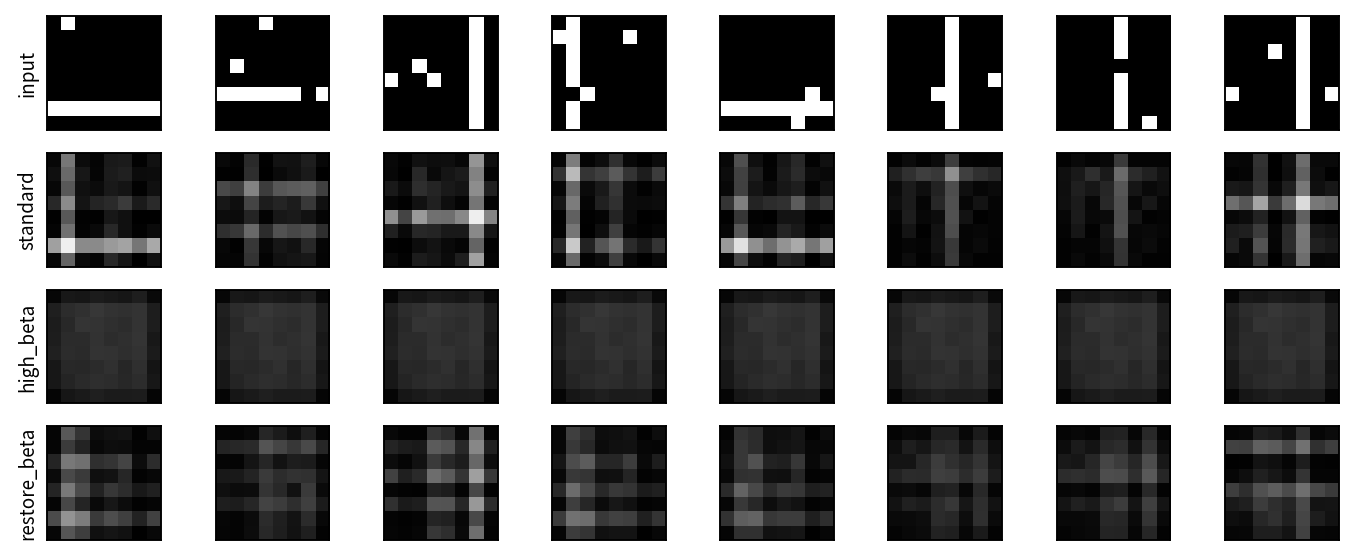

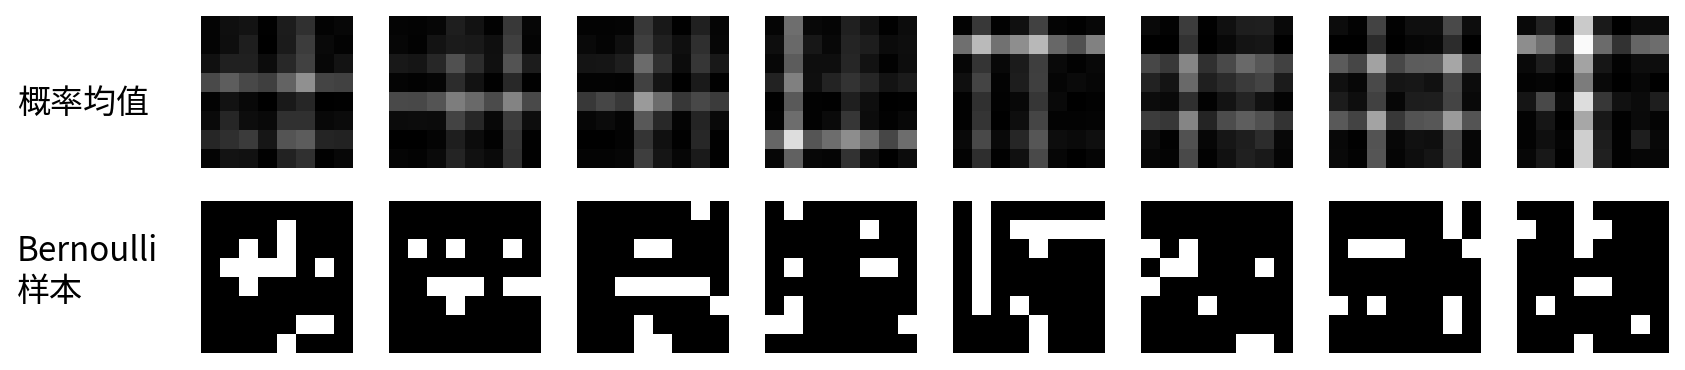

In [8]:
from IPython.display import display,Image
display(Image(filename=str(ROOT/"figures/02_image_reconstruction.png")))
display(Image(filename=str(ROOT/"figures/06_image_samples.png")))


## 8 写下结论
完成十题，说明观测模型、nat/例、MC估计与诱发坍塌边界。不要把生成均值当真正样本，也不要把下界当精确似然。